<a href="https://colab.research.google.com/github/kunal-garg-1/French_Art_Classifier/blob/main/French_Art_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1: Data Acquisition

In [7]:
!pip install -q bing-image-downloader

In [2]:
from bing_image_downloader import downloader
from pathlib import Path
from fastai.vision.utils import resize_images

# 1. Set up our categories (added 'painting' directly to the folder name for accuracy)
painters = ['Claude Monet painting', 'Pierre-Auguste Renoir painting', 'Edgar Degas painting', 'Paul Cezanne painting']
dataset_dir = Path('french_art')

# 2. The Bing Scraper Loop
for painter in painters:
    print(f"\n--- Sourcing gallery for: {painter} ---")

    # This built-in function handles the downloading, folder creation, and error catching!
    downloader.download(
        painter,
        limit=100,  # 100 images is the sweet spot for transfer learning
        output_dir=dataset_dir,
        adult_filter_off=True,
        force_replace=False,
        timeout=60,
        verbose=False # Keeps the terminal output clean and readable
    )

print("\n✅ Done downloading the raw gallery from Bing!")

# 3. Compress the Data (Crucial for Colab RAM)
print("Resizing images to save memory... (This might take a minute)")
for painter in painters:
    # Bing creates a folder named exactly after our search query
    folder_path = dataset_dir/painter

    # Fast.ai resizes them to 400x400 pixels
    resize_images(folder_path, max_size=400, dest=folder_path)

print("✅ Resizing complete! The data is ready.")


--- Sourcing gallery for: Claude Monet painting ---
[%] Downloading Images to /content/french_art/Claude Monet painting
[!] Issue getting: https://www.eesel.ai/_next/image?url=https:%2F%2Fwebsite-cms.eesel.ai%2Fwp-content%2Fuploads%2F2025%2F09%2FBanner-Anthropic-launches-Claude-for-Chrome_-Heres-what-you-need-to-know.png&w=1080&q=80
[!] Error:: HTTP Error 400: Bad Request
[!] Issue getting: https://www.claudeaiweb.com/wp-content/uploads/2025/03/claude-ai-desktop-app-768x590.webp
[!] Error:: HTTP Error 404: Not Found
[!] Issue getting: https://www.techshark.io/media/tool_logo/Claude_AI_Logo.png
[!] Error:: <urlopen error [Errno -2] Name or service not known>
[!] Issue getting: https://cdn2.downdetector.com/static/uploads/logo/Claude_AI_logo.svg
[!] Error:: Invalid image, not saving https://cdn2.downdetector.com/static/uploads/logo/Claude_AI_logo.svg
[!] Issue getting: https://www.eesel.ai/_next/image?url=https:%2F%2Fwebsite-cms.eesel.ai%2Fwp-content%2Fuploads%2F2025%2F06%2FMain-Bottom-

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


✅ Resizing complete! The data is ready.


#Phase 2: Data Cleaning

In [13]:
# To make sure we have the fast.ai library imported
from fastai.vision.all import *

# 1. Point to our main dataset folder
path = Path('french_art')

# 2. Grab every single image file inside all the sub-folders
image_files = get_image_files(path)
print(f"Total raw images found: {len(image_files)}")

# 3. Ask fast.ai to attempt to open every image and check for corruption
failed = verify_images(image_files)
print(f"Number of corrupted images found: {len(failed)}")

# 4. Automatically delete the broken ones
failed.map(Path.unlink)
print("✅ Cleaning complete. The gallery is pristine!")

Total raw images found: 223
Number of corrupted images found: 0
✅ Cleaning complete. The gallery is pristine!


#Phase 3: The DataBlock API

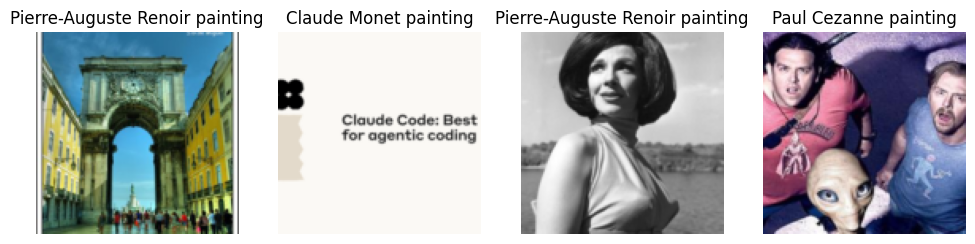

In [14]:
# 1. Define the blueprint for the data pipeline
art_datablock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128)
)

# 2. Pour the actual images into the blueprint to create DataLoaders
dls = art_datablock.dataloaders(path)

# 3. Show a batch of the data to verify it worked
dls.valid.show_batch(max_n=4, nrows=1)

#Phase 4: Transfer Learning

In [15]:
# 1. Build the Learner (combining our data, the ResNet18 brain, and an error metric)
learn = vision_learner(dls, resnet18, metrics=error_rate)

# 2. Fine-tune the model for 3 epochs (cycles)
print("Training the model on our messy dataset...")
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 60.5MB/s]


Training the model on our messy dataset...


epoch,train_loss,valid_loss,error_rate,time
0,2.593824,2.228388,0.568182,00:03


epoch,train_loss,valid_loss,error_rate,time
0,1.821963,1.310770,0.477273,00:00
1,1.473194,0.733427,0.204545,00:00
2,1.155092,0.519495,0.113636,00:00


#Phase 5: Evaluation & The GUI Cleaner

--- Confusion Matrix ---



--- Top Losses (The Garbage Data) ---


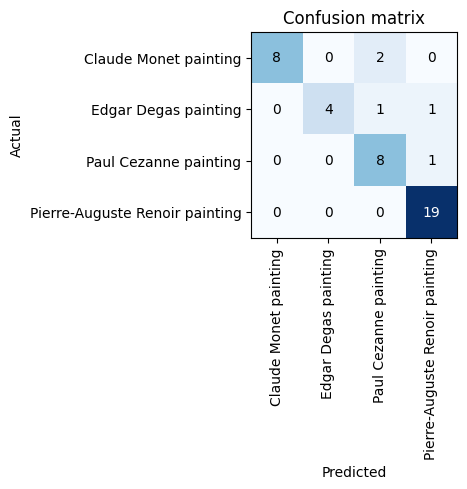

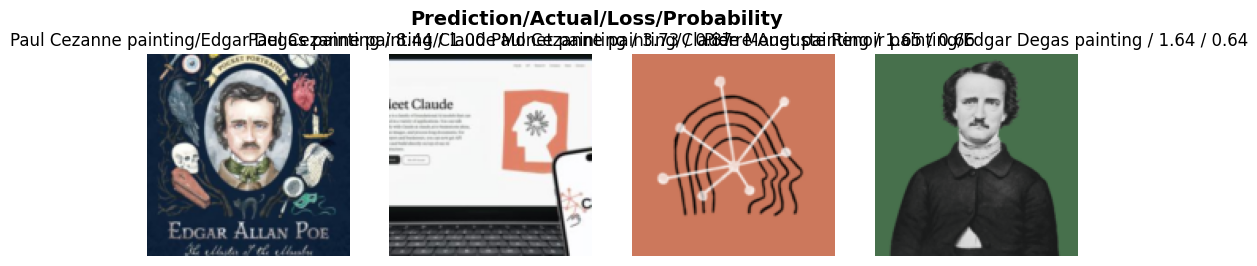

In [16]:
# 1. Import the widget tools
from fastai.vision.widgets import *

# 2. Build the Confusion Matrix to see where the AI struggled
interp = ClassificationInterpretation.from_learner(learn)
print("--- Confusion Matrix ---")
interp.plot_confusion_matrix()

# 3. Show the top 4 images with the highest "Loss" (The ones that confused the AI the most)
print("\n--- Top Losses (The Garbage Data) ---")
interp.plot_top_losses(4, nrows=1)

# 4. Launch the GUI Cleaner
cleaner = ImageClassifierCleaner(learn)
cleaner

#Phase 5.5: The Re-Train

In [17]:
# 1. PERMANENTLY DELETE the files you flagged in the GUI
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
print("Garbage files deleted!")

# 2. Re-load the DataLoaders (so PyTorch realizes the bad files are gone)
dls = art_datablock.dataloaders(path)

# 3. Create a fresh Learner so it forgets the old training
learn = vision_learner(dls, resnet18, metrics=error_rate)

# 4. Fine-tune the model one last time on the pristine dataset!
print("Re-training on the pristine gallery...")
learn.fine_tune(3)

Garbage files deleted!
Re-training on the pristine gallery...


epoch,train_loss,valid_loss,error_rate,time
0,2.432944,2.574918,0.651163,00:00


epoch,train_loss,valid_loss,error_rate,time
0,1.700730,1.616656,0.534884,00:00
1,1.389970,1.081106,0.395349,00:00
2,1.123813,0.850424,0.348837,00:00


#Phase 6: Export & Deploy

In [18]:
# Export the entire trained model (architecture + weights + vocabulary) into a single file
learn.export('french_art_model.pkl')

print("✅ Model successfully exported!")

✅ Model successfully exported!
